In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pyccl as ccl
import pandas as pd
import pylab as plt

<h3> I define the global configuration </h3>

In [3]:
config_global = dict(
                    H0 = 68.1,
                    Om_m = 0.306, # Omega matter
                    Om_b = 0.0486, # Omega baryons
                    sigma8 = 0.807,
                    n_s = 0.967,
                    num_k = 10001,
                    rp_model_min = 7.391, # Minimum transverse distance to model in Mpc
                    rp_model_max = 128.016, # Maximum transverse distance to model in Mpc
                    bins_rp_model = 16, # Number of transverse distance bins
                    log10kmin = -5, # minimum k
                    log10kmax = 2, # maximum k
                    l_min = 0, # Minimum l
                    l_max = 10001, # Maximum l
                    steps_l = 10, # Steps in l
                    IA_model = 'TATT', # Model for IA
                    min_scale_cut = 5, # Minimum scale cut to apply in the correlation function in Mpc/h (in case you want to run chains)
                    max_scale_cut = 100, # Maximum scale cut to apply in the correlation function in Mpc/h (in case you want to run chains)
)

<h3> I update the config setup </h3>

In [4]:
from IATheory.process_config import init_cosmology, init_grids, init_pt_calculators, compute_kernels_spec, init_lightcone, init_photometric, update_global_config, build_specific_config

In [5]:
# We need to perform some initial computations from the global configuration. This includes definining the CCL cosmo library, define k and rp arrays and initialise PT calculators.
config_global = update_global_config(config_global)

<h3> Initialise the modelling class </h3>

In [6]:
from IATheory.compute_observables import model_2p_corr

In [7]:
galaxy_bias = [1.2, -0.4]
ia_params = [0.5, 1, 1.5]
model = model_2p_corr(config_global, galaxy_bias, ia_params)
print(model.__doc__)


    This class computes projected galaxy-galaxy (wgg) and galaxy-shear (wg+) correlation functions.
    It also allows to compute these observables in the lightcone and in the snapshot.
    In the case of the snapshot, it can model spectroscopic and photometric redshifts cases.

    Arguments:
    -----------
        galaxy_bias (nunmpy array): Galaxy bias values
        ia_params (nunmpy array): Intrinsic alignment values

    Attributes:
    -----------
        config (dict): Configuration dictionary for the computation.
        wgg_spec_snapshot (object, optional): Projected galaxy-galaxy (position-position) correlation function with spectroscopic redshifts in the snapshot.
        wgg_spec_lightcone (object, optional): Projected galaxy-galaxy (position-position) correlation function with spectroscopic redshifts in the lightcone.
        wgg_phot_lightcone (object, optional): Projected galaxy-galaxy (position-position) correlation function with photometric redshifts in the lightcon

<h3> Define plotting function </h3>

In [8]:
def plot_wgg_wgp(rp_model, wgg, wgp):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
    ax1.plot(rp_model, wgg)
    ax1.set_xlabel(r'$r_{p}$', fontsize = 14)
    ax1.set_ylabel(r'$w_{gg}$', fontsize = 14)

    ax2.plot(rp_model, wgp)
    ax2.set_xlabel(r'$r_{p}$', fontsize = 14)
    ax2.set_ylabel(r'$w_{gp}$', fontsize = 14)
    plt.tight_layout()
    plt.show()

<h2> Cases using the box </h2>

<h3> Compute galaxy clustering (wgg) and intrinsic alignments (wgp) </h3>

In [9]:
case = 'box'
config_setup_box = dict(z_snapshot=0) #redshift of the snapshot
config_box = build_specific_config(config_global, config_setup_box, case)

In [10]:
model.model_wgg_spec_snapshot(config_box)
model.model_wgp_spec_snapshot(config_box)

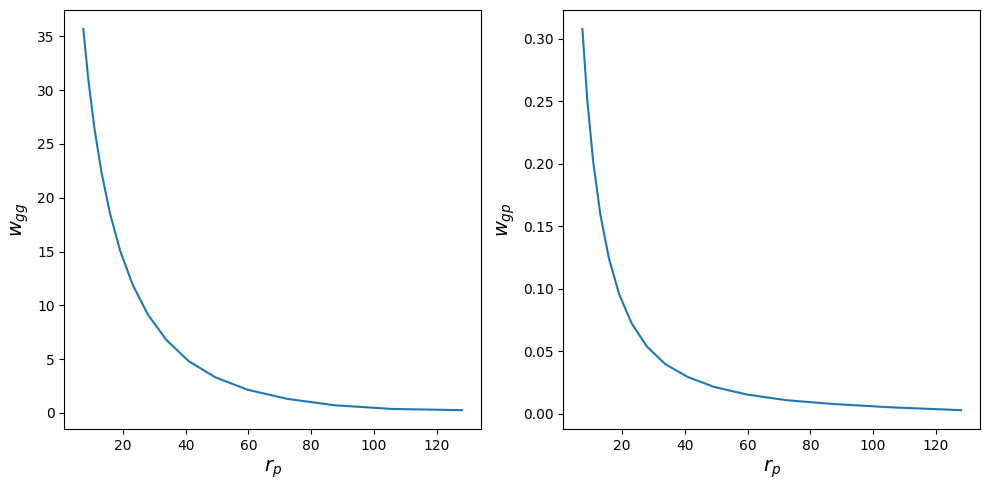

In [11]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_spec_snapshot.xi, model.wgp_spec_snapshot.xi)

<h2> Cases using the lightcone </h2>

<h3> Spec-z </h3>

In [12]:
case = 'lightcone_spec'
config_setup_lightcone_spec = dict(z_min = 0., # Minimum redshift to model
                                   z_max = 1.1, # Maximum redshift to model
                                   z_type = 'spec', # It can either be "phot" or "spec"
                                  )
config_lightcone_spec = build_specific_config(config_global, config_setup_lightcone_spec, case)

In [13]:
model.model_wgg_spec_lightcone(config_lightcone_spec)
model.model_wgp_spec_lightcone(config_lightcone_spec)

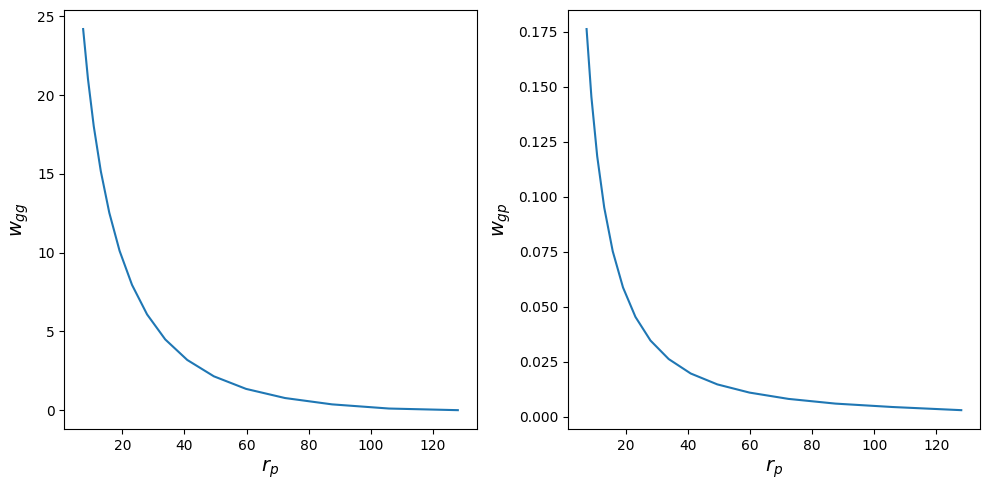

In [14]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_spec_lightcone.xi, model.wgp_spec_lightcone.xi)

<h3> Photo-z </h3>

In [15]:
case = 'lightcone_phot'
config_setup_lightcone_phot = dict(z_min = 0., # Minimum redshift to model
                                   z_max = 1.1, # Maximum redshift to model
                                   z_type = 'phot', # It can either be "phot" or "spec"
                                   Pi = np.array([-233,-144,-89,-55,-34,-21,-13,-8,-5,-3,-2,-1,0,1,2,3,5,8,13,21,34,55,89,144,233]), # Pi binning (in Mpc)
                                   bins_zm = 10, # Number of redshift bins for the error distribution in the phot case
                                   add_magnification = True, # This boolean is used in the case of correlation functions with photometric redshifts to indicate whether to include magnification as a contaminant or not.
                                   add_galaxy_galaxy_lensing = True, # This boolean is used in the case of correlation functions with photometric redshifts to indicate whether to include magnification as a contaminant or not.
                                   )
config_lightcone_phot = build_specific_config(config_global, config_setup_lightcone_phot, case)

In [16]:
model.model_wgg_phot_lightcone(config_lightcone_phot)
model.model_wgp_phot_lightcone(config_lightcone_phot)

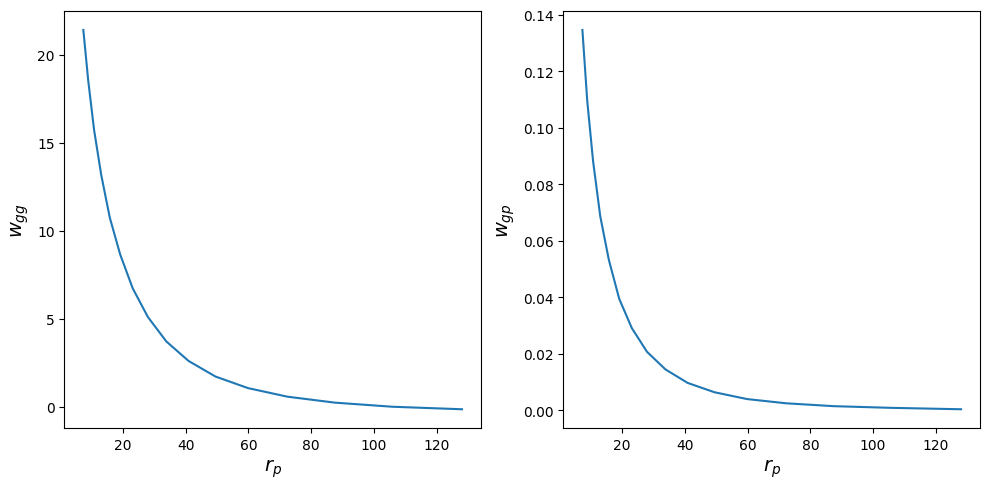

In [17]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_phot_lightcone.xi, model.wgp_phot_lightcone.xi)